# **멀티 모달 AI의 성장**

# **VLM Vision-Language Model**

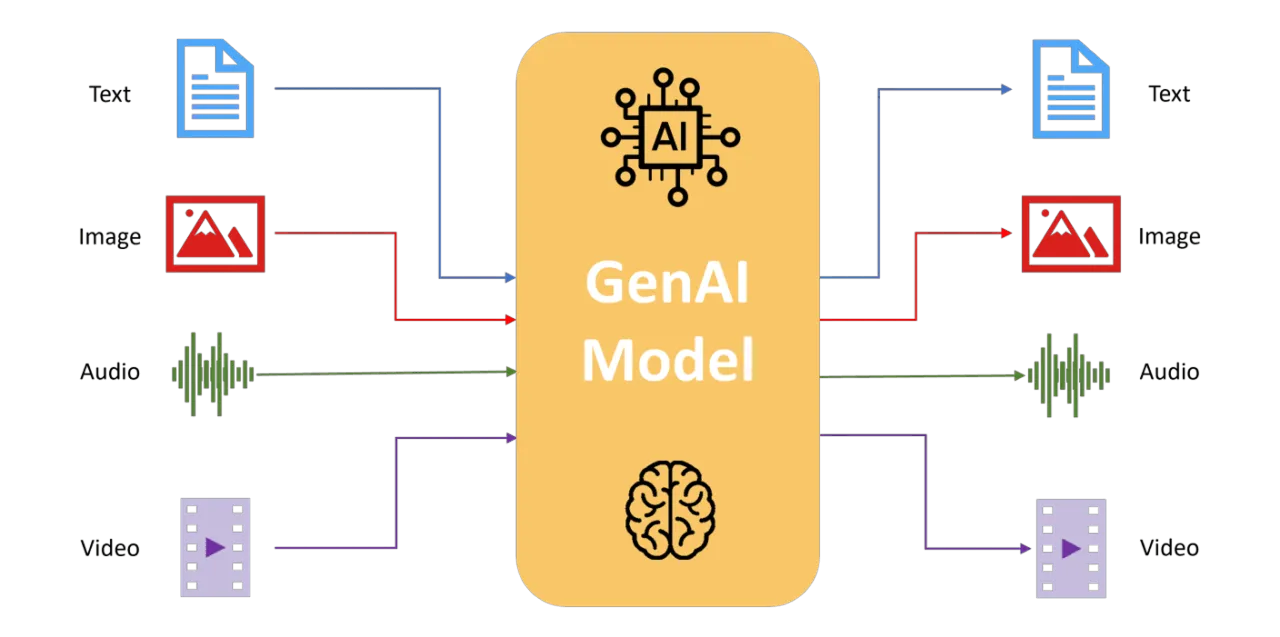

https://www.ultralytics.com/ko/blog/multi-modal-models-and-multi-modal-learning-expanding-ais-capabilities

# **CLIP**: Connecting text and images

## 이미지와 텍스트를 연결하다.

Learning Transferable Visual Models From Natural Language Supervision, Alec Radford, ICML2021, OpenAI

https://openai.com/index/clip/

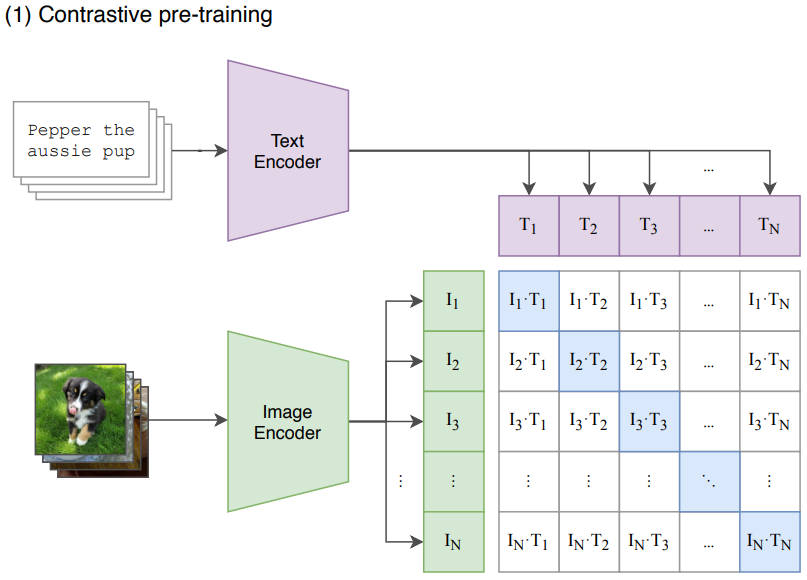

## 4억건의 이미지와 라벨 정보를 이용해서 Text Encoder와 Image Encoder가 유사한 벡터가 되도록 학습

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
!pip install pillow


In [ ]:
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# CLIP 모델 로드
model, preprocess = clip.load("ViT-B/32", device=device)


| 모델             | Vision Backbone      | Text Backbone | 특징             |
| -------------- | -------------------- | ------------- | -------------- |
| RN50           | ResNet-50            | Transformer   | 가장 가벼움         |
| RN101          | ResNet-101           | Transformer   | 더 깊은 CNN       |
| RN50x4         | ResNet-50 (4x wide)  | Transformer   | 성능 증가          |
| RN50x16        | ResNet-50 (16x wide) | Transformer   | 매우 크고 강함       |
| RN50x64        | ResNet-50 (64x wide) | Transformer   | 가장 큰 ResNet 기반 |
| ViT-B/32       | ViT-Base / 32patch   | Transformer   | 가벼운 ViT        |
| ViT-B/16       | ViT-Base / 16patch   | Transformer   | 높은 품질          |
| ViT-L/14       | ViT-Large / 14patch  | Transformer   | CLIP 대표 모델     |
| ViT-L/14@336px | ViT-L/14, 고해상도       | Transformer   | 분류/검색 성능 최고    |


In [ ]:
# 예시: 강아지 이미지
image_url = "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content)).convert("RGB")
display(image)


In [ ]:
# 1) 텍스트 프롬프트들
text_prompts = [
    "a photo of a dog",
    "a photo of a cat",
    "a photo of a car",
    "a photo of a bird",
    "a photo of a shiba inu",
    "a close-up portrait of a dog",
    "강아지 사진입니다",
    "개 사진입니다",
]

# 2) 전처리
image_input = preprocess(image).unsqueeze(0).to(device)
text_tokens = clip.tokenize(text_prompts).to(device)

# 3) 인코딩 & 유사도 계산
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_tokens)

    # CLIP이 내부적으로 사용하는 로짓 (유사도 점수)
    logits_per_image, logits_per_text = model(image_input, text_tokens)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

for label, p in zip(text_prompts, probs):
    print(f"{label:25s} -> {p*100:5.2f}%")


### Stable Diffusion은 이미지의 캡션 정보를 CLIP의 Text Embedding을 이용해 생성과정에 관여하도록 설계

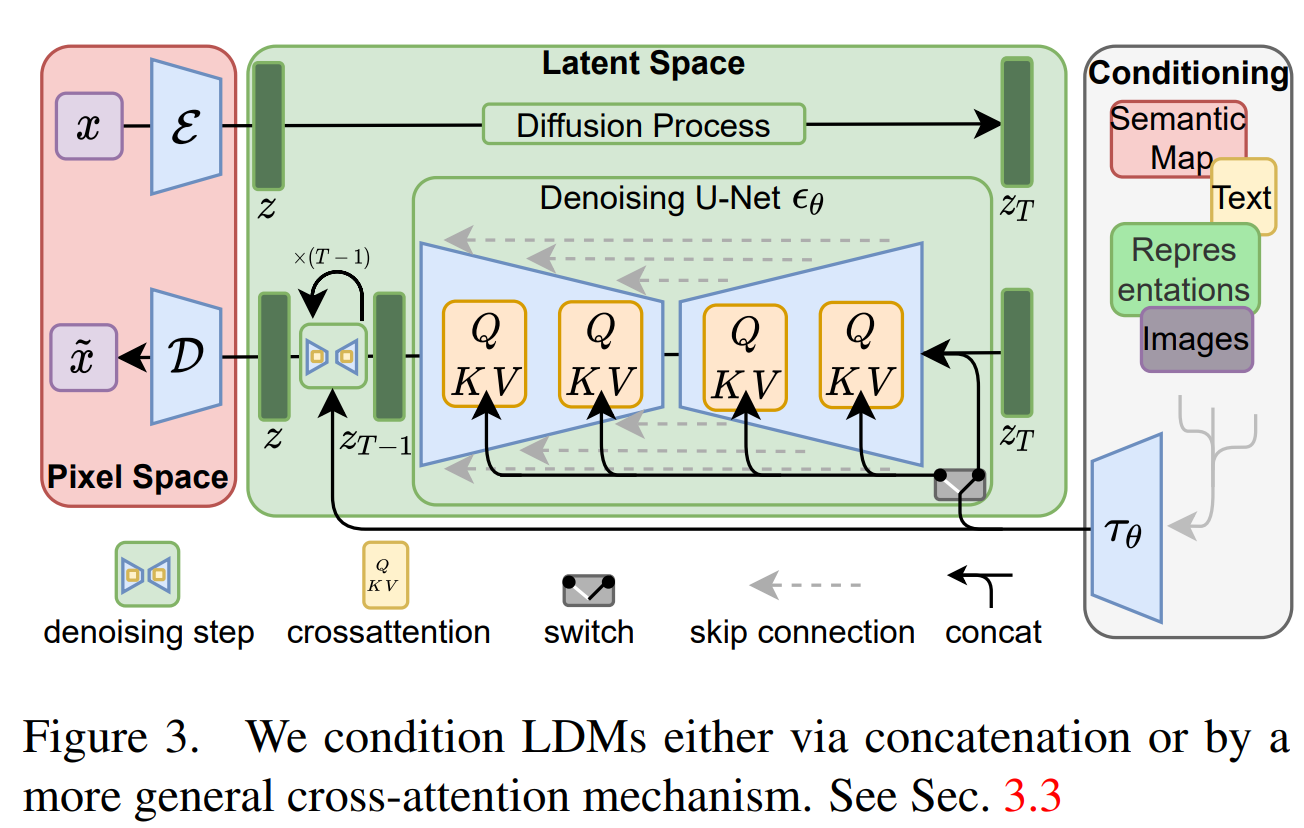

https://arxiv.org/abs/2112.10752

# **ViT (Vision Transformer)의 등장**

### “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale”

### by Alexey Dosovitskiy et al. (2020)

https://arxiv.org/abs/2010.11929?utm_source=chatgpt.com

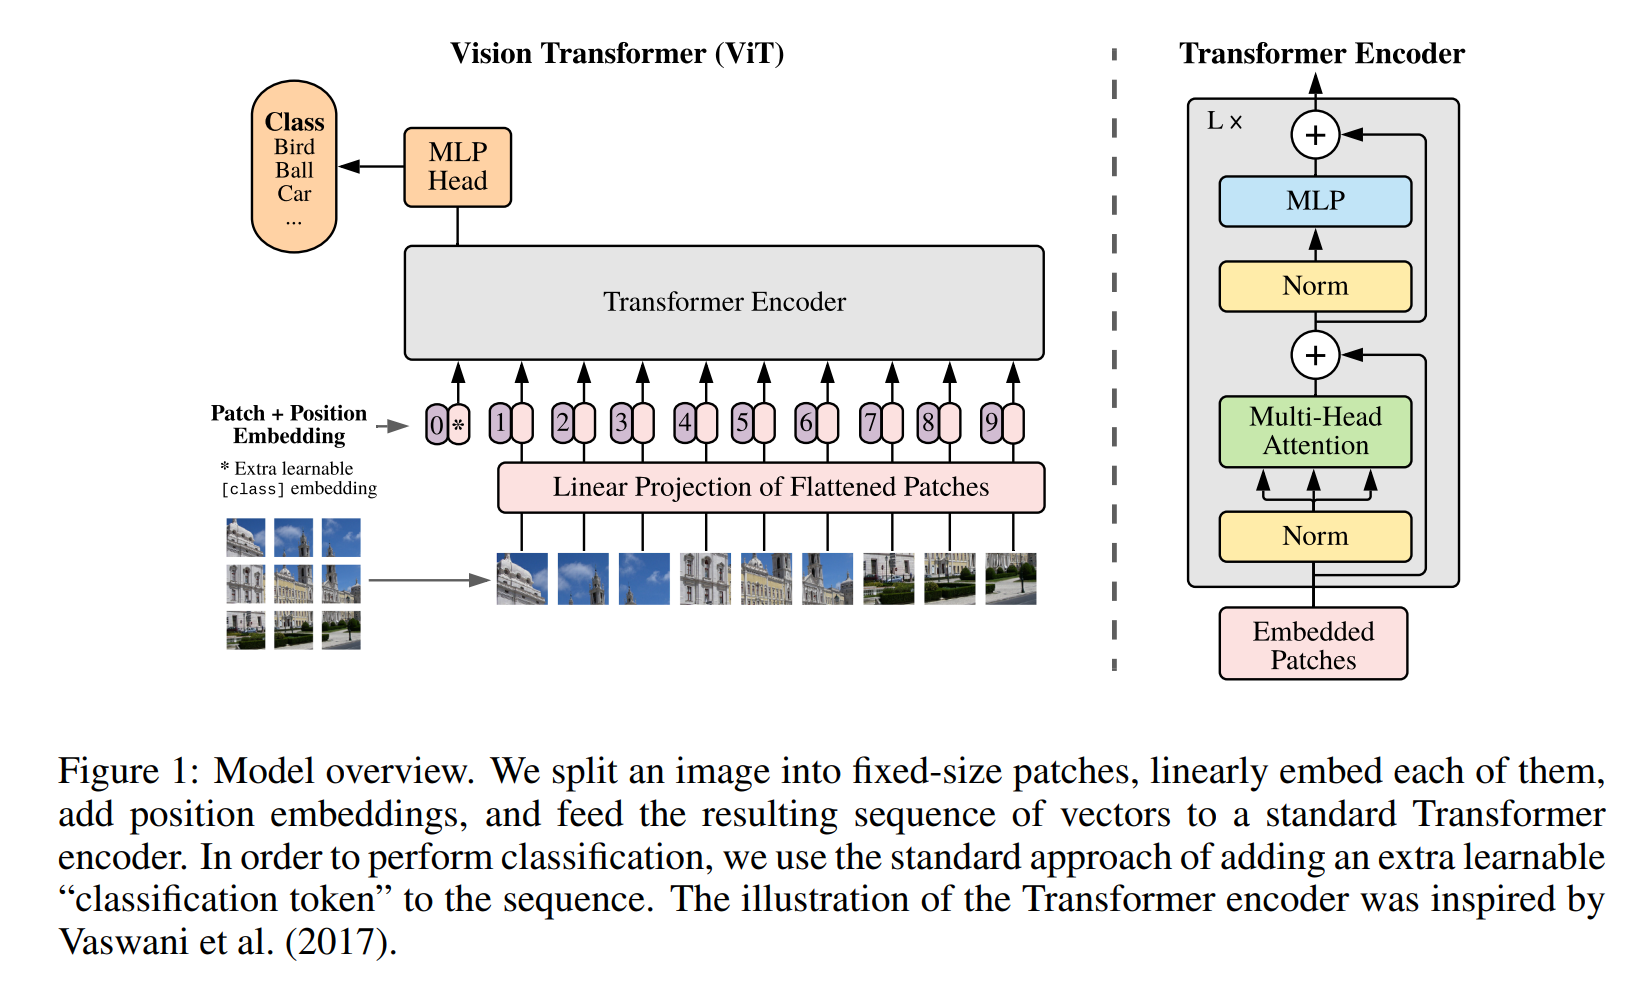

# **Masked Autoencoder (MAE)** 등장으로 ViT의 성능 대폭 개선

## Masked Autoencoders Are Scalable Vision Learners

(2021) Kaiming He, Xinlei Chen, Saining Xie, Yanghao Li, Piotr Dollár, Ross Girshick





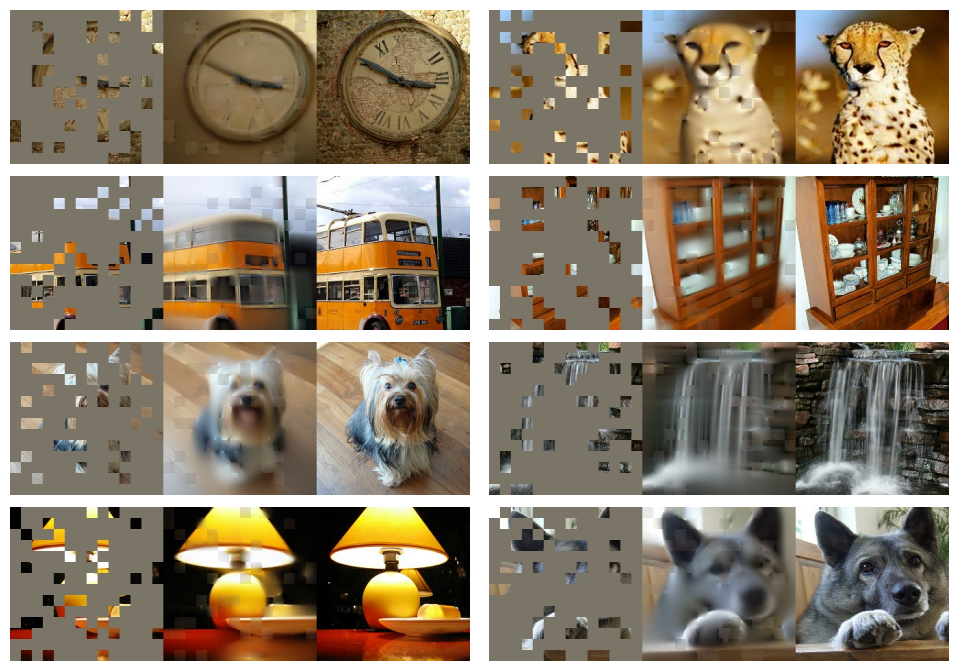

In [ ]:
!pip install transformers timm einops -q

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import ViTFeatureExtractor, ViTMAEForPreTraining
import requests
from PIL import Image

# 1) Feature extractor & 모델 로드
feature_extractor = ViTFeatureExtractor.from_pretrained("facebook/vit-mae-base")
imagenet_mean = np.array(feature_extractor.image_mean)
imagenet_std = np.array(feature_extractor.image_std)

model = ViTMAEForPreTraining.from_pretrained("facebook/vit-mae-base")

In [ ]:

# 2) 보조 함수들 (이미지 디노멀라이즈 + 표시)
def show_image(image, title=''):
    # image: [H, W, 3]
    assert image.shape[2] == 3
    # MAE는 imagenet mean/std로 정규화된 상태 → 다시 되돌려서 0~255로
    img = (image * imagenet_std + imagenet_mean) * 255
    img = np.clip(img, 0, 255).astype(np.uint8)
    plt.imshow(img)
    plt.title(title, fontsize=14)
    plt.axis("off")

def visualize(pixel_values, model):
    """
    pixel_values: [1, 3, 224, 224]
    """
    with torch.no_grad():
        outputs = model(pixel_values)

    # ① 복원 결과 logits → (N, 3, H, W) 이미지로 unpatchify
    y = model.unpatchify(outputs.logits)
    # (N, C, H, W) → (N, H, W, C)
    y = torch.einsum("nchw->nhwc", y).detach().cpu().numpy()

    # ② mask: 어떤 패치가 가려졌는지 (1: masked, 0: visible)
    mask = outputs.mask.detach()
    # (N, L) → 각 패치를 p*p*3 픽셀로 확장
    mask = mask.unsqueeze(-1).repeat(
        1, 1, model.config.patch_size ** 2 * 3
    )  # (N, H*W, p*p*3)
    mask = model.unpatchify(mask)  # (N, 3, H, W)
    mask = torch.einsum("nchw->nhwc", mask).detach().cpu().numpy()

    # ③ 원본 입력 (정규화된 pixel_values) → (N, H, W, C)
    x = torch.einsum("nchw->nhwc", pixel_values).detach().cpu().numpy()

    # ④ 마스크 적용된 입력 / 복원 결과 합성
    im_masked = x * (1 - mask)            # 보이는 패치만 남긴 이미지
    im_paste = x * (1 - mask) + y * mask  # 보이는 패치 + 복원된 패치

    # ⑤ 시각화
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    show_image(x[0], "Original")

    plt.subplot(1, 4, 2)
    show_image(im_masked[0], "Masked Input")

    plt.subplot(1, 4, 3)
    show_image(y[0], "MAE Reconstruction")

    plt.subplot(1, 4, 4)
    show_image(im_paste[0], "Reconstruction + Visible")

    plt.tight_layout()
    plt.show()


In [ ]:
# 3) 테스트용 이미지 로드
url = "https://user-images.githubusercontent.com/11435359/147738734-196fd92f-9260-48d5-ba7e-bf103d29364d.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
display(image)



In [ ]:

# 4) 전처리 → pixel_values
pixel_values = feature_extractor(image, return_tensors="pt").pixel_values


# 5) 시각화 실행
visualize(pixel_values, model)

# **ViT - LLM 연결**

# **이미지 패치 토큰을 직접 LLM에 입력해서 이미지토큰과 Text토큰이 self attention하도록**



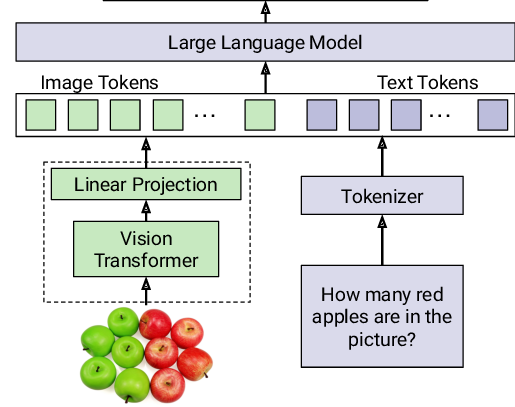

[Submitted on 17 Aug 2025]

LangVision-LoRA-NAS: Neural Architecture Search for Variable LoRA Rank in Vision Language Models

Krishna Teja Chitty-Venkata, Murali Emani, Venkatram Vishwanath


https://arxiv.org/abs/2508.12512

# **표준기술**

## BLIP-2: Bootstrapping Language-Image Pre-training with Frozen Image Encoders and Large Language Models

https://arxiv.org/abs/2301.12597

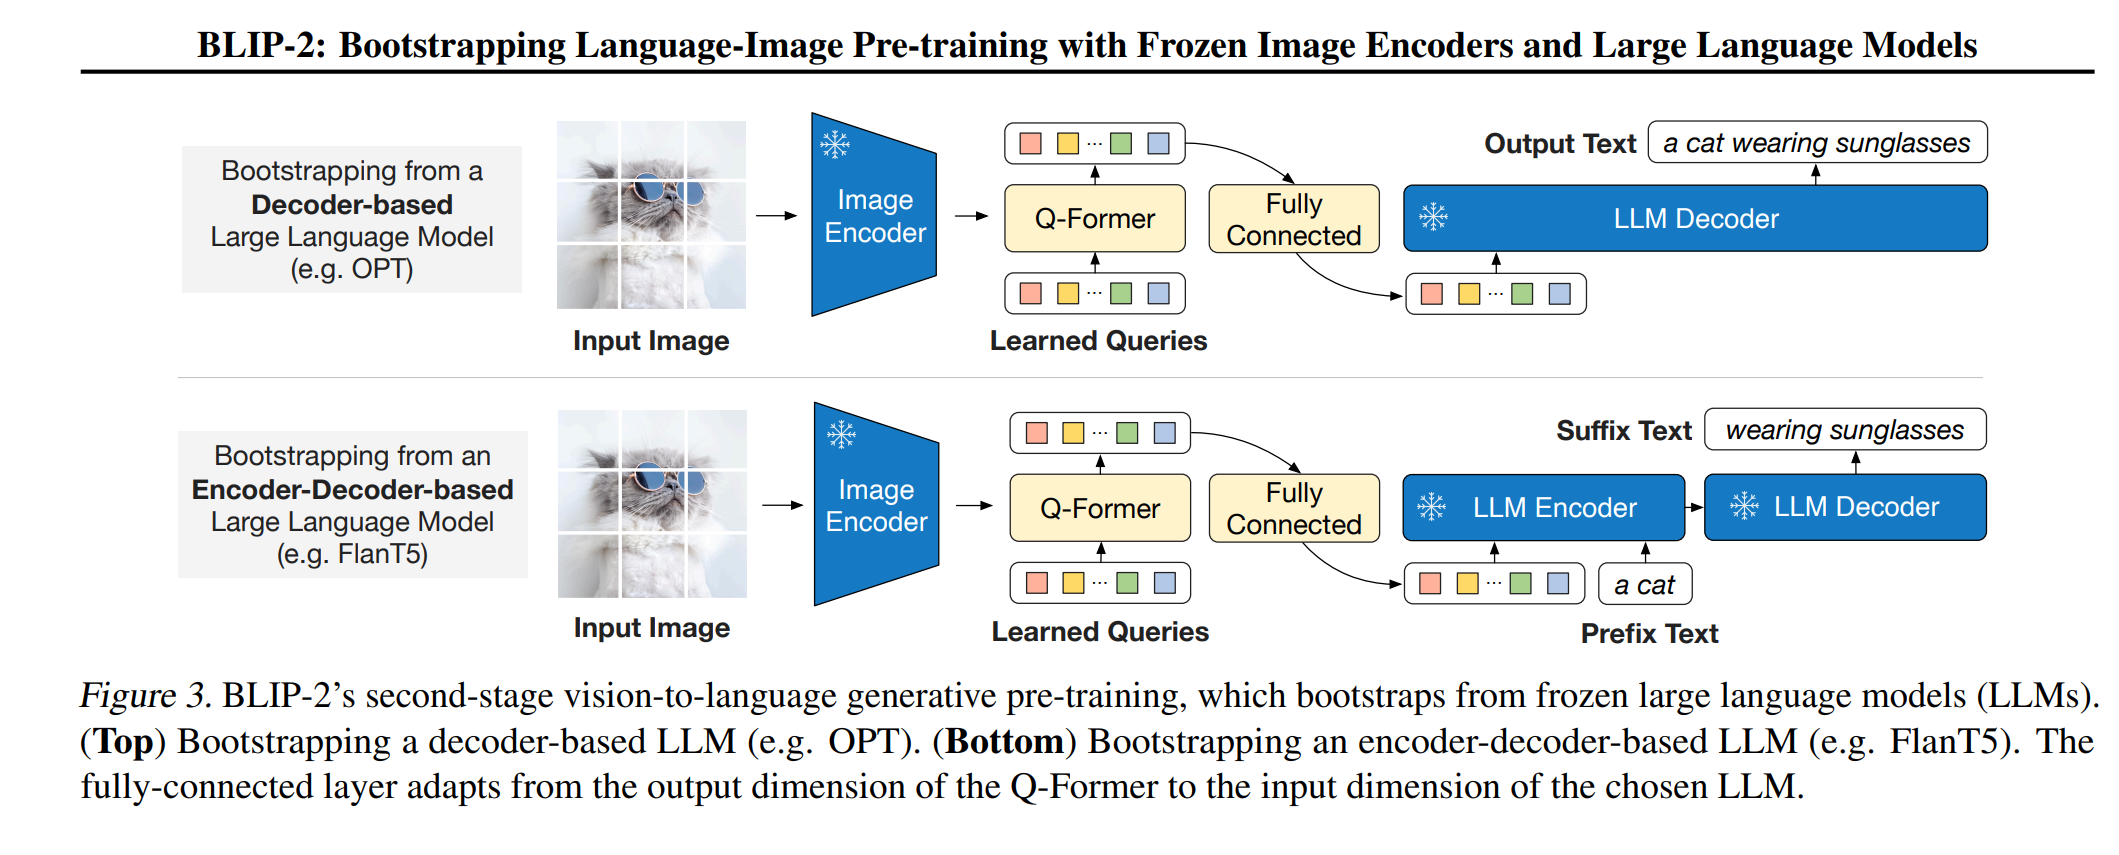

In [ ]:
!pip install -q transformers accelerate sentencepiece safetensors

import torch
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from PIL import Image
import requests

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

model_name = "Salesforce/blip2-flan-t5-xl"

processor = Blip2Processor.from_pretrained(model_name)
model = Blip2ForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

In [ ]:
# 예시: 강아지 이미지
image_url = "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")
display(image)


In [ ]:
# # 직접 파일 업로드 해서 보고 싶으면 실행
# from google.colab import files
# uploaded = files.upload()  # 이미지 파일 선택

# img_name = list(uploaded.keys())[0]
# image = Image.open(img_name).convert("RGB")
# display(image)


In [ ]:


prompt = "Describe the image in detail."

inputs = processor(image, prompt, return_tensors="pt").to(device, torch.float16)

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=100
    )

generated_text = processor.decode(generated_ids[0], skip_special_tokens=True)
print("📝 Generated text:")
print(generated_text)


# **이제는 Q-former도 필요 없이 LLM이 완벽하게 이미지를 이해하고 텍스트와 동시에 이해하는 수준으로 발전**

# **DiTs(Diffusion Transformers) 이미지 생성도 Transformer 시대**

[Submitted on 19 Dec 2022 (v1), last revised 2 Mar 2023 (this version, v2)]

## Scalable Diffusion Models with Transformers

William Peebles, Saining Xie

https://arxiv.org/abs/2212.09748?utm_source=chatgpt.com

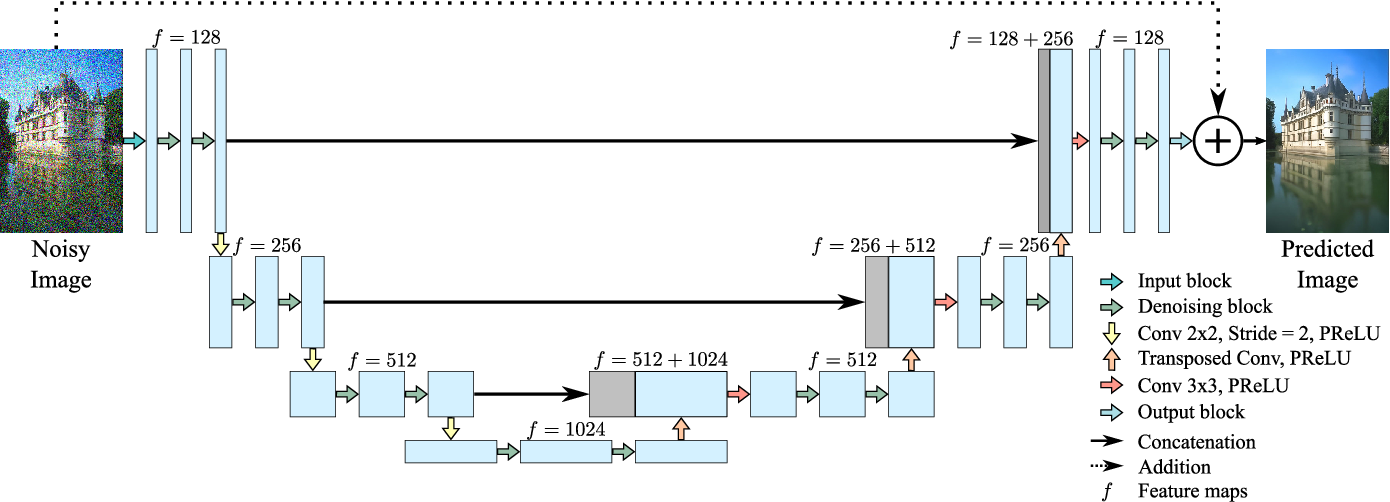

🟩 DiT가 U-Net과 다른 핵심 5개 포인트
✔ 1) Patchify / Unpatchify

U-Net은 CNN conv 기반이라 픽셀 공간 그대로 처리
DiT는 Vision Transformer처럼 패치 단위로 이미지 latent를 분해함

✔ 2) Self-Attention 기반

U-Net은 2D convolution + skip
DiT는 전체 이미지 패치 간 attention → 더 global한 정보 처리

✔ 3) 시간 정보(timestep embedding) 삽입 방식이 Transformer식

U-Net: Adaptive Group Norm (AdaGN)

DiT: 각 Transformer block에 t-embedding을 입력 projection으로 injection

✔ 4) 조건 입력(class, text)도 attention에 자연스럽게 융합

→ text-to-image, class-conditional에 더 강함

✔ 5) scaling 성능이 매우 뛰어남

논문에서 2억~10억 모델까지 scaling 해도
U-Net보다 성능이 더 잘 나왔다.